In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_4_ch_52.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_3_ch_57.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_2_ch_52.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_5_ch_57.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_2_ch_57.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_1_ch_58.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_4_ch_55.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_1_ch_59.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_1_ch_51.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_4_ch_57.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_4_ch_51.png
/kaggle/input/dataset-seed-for-s1s1/dataset_eeg/test/Fear/trial_2_band_5_ch_56.png
/kag

In [4]:
import os
import torch
import torch.nn as nn
from transformers import ViTModel, ViTConfig
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define dataset directory paths
DATASET_PATH = "/kaggle/input/dataset-seed-for-s1s1/dataset_eeg"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

# Define transformations for image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for ViT
    transforms.Grayscale(3),  # Convert grayscale to RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1, 0.1, 0.1], std=[0.1, 0.1, 0.1])
])

# Load dataset using ImageFolder
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Check class indices (ASD -> 0, NonASD -> 1)
print(train_dataset.class_to_idx)  # Example output: {'ASD': 0, 'NonASD': 1}

{'Disgust': 0, 'Fear': 1, 'Happy': 2, 'Neutral': 3, 'Sad': 4}


In [5]:
class ViTClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(ViTClassifier, self).__init__()
        config = ViTConfig(
            hidden_size=768,
            num_attention_heads=12,
            num_hidden_layers=12,
            intermediate_size=3072,
            image_size=224,
            patch_size=16,
            num_channels=3,  # RGB images
            num_labels=num_classes
        )
        self.vit = ViTModel(config)
        self.classifier = nn.Linear(config.hidden_size, num_classes)

    def forward(self, x):
        x = self.vit(x)['last_hidden_state']
        output = self.classifier(x[:, 0, :])  # Use CLS token embedding
        return output

In [6]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, optimizer, and loss function
model = ViTClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Training function
def train(model, dataloader, optimizer, criterion, epochs=5):
    model.train()
    for epoch in range(epochs):
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        total_loss = 0
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            loop.set_postfix(loss=total_loss / len(dataloader))
    print("Training complete.")

# Train the model
train(model, train_loader, optimizer, criterion)

Epoch 5/5: 100%|██████████| 40/40 [01:19<00:00,  1.98s/it, loss=0.972]

Training complete.


In [7]:
def evaluate(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Evaluate on test set
evaluate(model, test_loader)

Test Accuracy: 76.92%


In [8]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification

# Define dataset path
DATASET_PATH = "/kaggle/input/dataset-seed-for-s1s1/dataset_eeg"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for ViT
    transforms.Grayscale(3),  # Convert grayscale to RGB if needed
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1, 0.1, 0.1], std=[0.1, 0.1, 0.1])  # Normalize
])

# Load datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Check class indices (e.g., {'ASD': 0, 'NonASD': 1})
print(train_dataset.class_to_idx)

{'Disgust': 0, 'Fear': 1, 'Happy': 2, 'Neutral': 3, 'Sad': 4}


In [9]:
from transformers import ViTFeatureExtractor, ViTForImageClassification

# Load pretrained ViT model
model_name = "google/vit-base-patch16-224-in21k"  # Pretrained on ImageNet-21k
model = ViTForImageClassification.from_pretrained(model_name, num_labels=5)

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

Epoch 10/10: 100%|██████████| 40/40 [01:19<00:00,  2.00s/it, acc=99.6, loss=0.0173] 


Training complete.


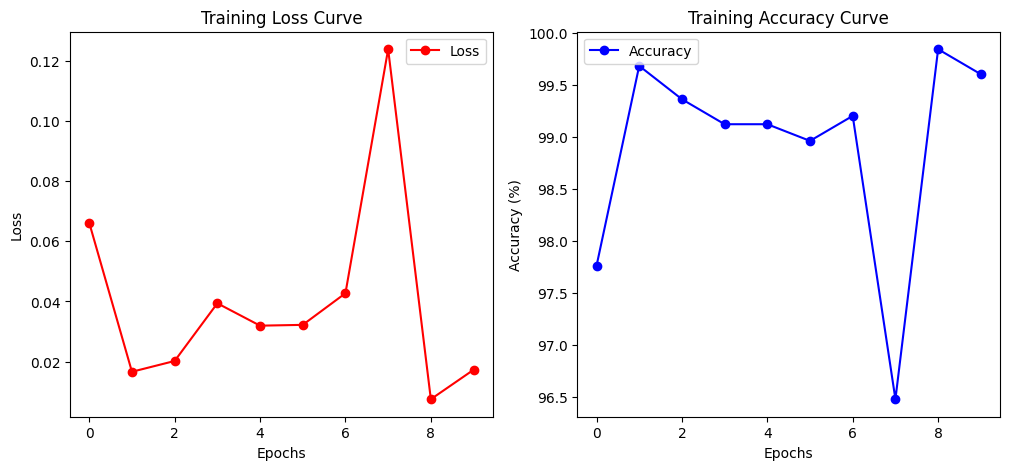

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training function with accuracy tracking
def train(model, dataloader, optimizer, criterion, epochs=10):
    model.train()
    
    train_losses = []
    train_accuracies = []
    
    for epoch in range(epochs):
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        total_loss = 0
        correct = 0
        total = 0
        
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images).logits  # Get logits
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # Compute Accuracy
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            loop.set_postfix(loss=total_loss / len(dataloader), acc=100 * correct / total)
        
        # Store loss and accuracy per epoch
        epoch_loss = total_loss / len(dataloader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
    
    print("Training complete.")
    
    # Plot loss and accuracy curves
    plot_learning_curves(train_losses, train_accuracies)

# Function to plot loss and accuracy curves
def plot_learning_curves(losses, accuracies):
    plt.figure(figsize=(12, 5))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(losses, label="Loss", marker='o', color='r')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(accuracies, label="Accuracy", marker='o', color='b')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training Accuracy Curve")
    plt.legend()
    
    plt.show()


train(model, train_loader, optimizer, criterion)


In [41]:
def evaluate(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Evaluate model
evaluate(model, test_loader)

Test Accuracy: 99.67%


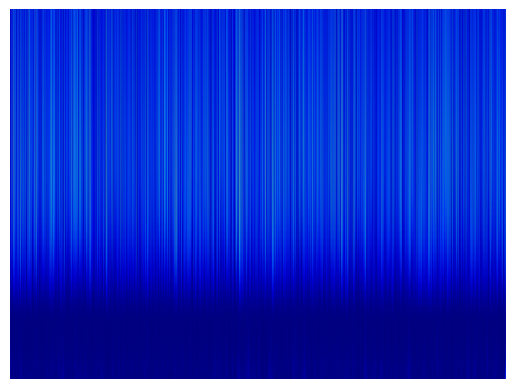

In [42]:
#fear 
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("/kaggle/input/meowww/trial_2_band_5_ch_57.png")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [43]:
import torch
import torchvision.transforms as transforms
from PIL import Image

def evaluate_single_image(model, image_path, class_labels):
    model.eval()  # Set model to evaluation mode

    # Define transformations (resize, convert to tensor, normalize)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Adjust based on model input size
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.1, 0.1, 0.1], std=[0.1, 0.1, 0.1])  # Adjust based on training settings
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert("L")  # Ensure it's in RGB format
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Perform inference
    with torch.no_grad():
        output = model(image).logits
        predicted_class = torch.argmax(output, dim=1).item()

    # Get class label
    class_label = class_labels[predicted_class] if class_labels else f"Class {predicted_class}"
    print(f"Predicted Class: {class_label}")

# Example usage
image_path = "/kaggle/input/meowww/trial_2_band_5_ch_57.png"  # Replace with actual image path
class_labels = ['Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']  # Modify based on your dataset
evaluate_single_image(model, image_path, class_labels)

Predicted Class: Fear


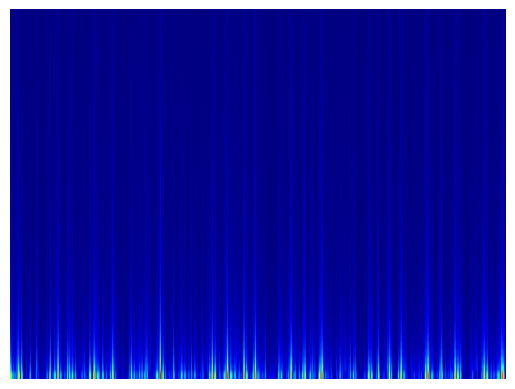

In [44]:
#happy
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("/kaggle/input/nekooo/trial_1_band_1_ch_56.png")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [45]:
import torch
import torchvision.transforms as transforms
from PIL import Image

def evaluate_single_image(model, image_path, class_labels):
    model.eval()  # Set model to evaluation mode

    # Define transformations (resize, convert to tensor, normalize)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Adjust based on model input size
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.1, 0.1, 0.1], std=[0.1, 0.1, 0.1])  # Adjust based on training settings
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert("L")  # Ensure it's in RGB format
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Perform inference
    with torch.no_grad():
        output = model(image).logits
        predicted_class = torch.argmax(output, dim=1).item()

    # Get class label
    class_label = class_labels[predicted_class] if class_labels else f"Class {predicted_class}"
    print(f"Predicted Class: {class_label}")

# Example usage
image_path = "/kaggle/input/nekooo/trial_1_band_1_ch_56.png"  # Replace with actual image path
class_labels = ['Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']  # Modify based on your dataset
evaluate_single_image(model, image_path, class_labels)

Predicted Class: Happy


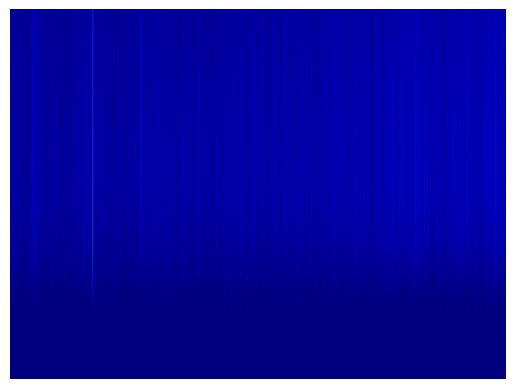

In [46]:
#disguist 
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("/kaggle/input/bokaaaa/trial_5_band_5_ch_59.png")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [49]:
import torch
import torchvision.transforms as transforms
from PIL import Image

def evaluate_single_image(model, image_path, class_labels):
    model.eval()  # Set model to evaluation mode

    # Define transformations (resize, convert to tensor, normalize)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Adjust based on model input size
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.1, 0.1, 0.1], std=[0.1, 0.1, 0.1])  # Adjust based on training settings
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert("L")  # Ensure it's in RGB format
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Perform inference
    with torch.no_grad():
        output = model(image).logits
        predicted_class = torch.argmax(output, dim=1).item()

    # Get class label
    class_label = class_labels[predicted_class] if class_labels else f"Class {predicted_class}"
    print(f"Predicted Class: {class_label}")

# Example usage
image_path = "/kaggle/input/bokaaaa/trial_5_band_5_ch_59.png"  # Replace with actual image path
class_labels = ['Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']  # Modify based on your dataset
evaluate_single_image(model, image_path, class_labels)

Predicted Class: Neutral


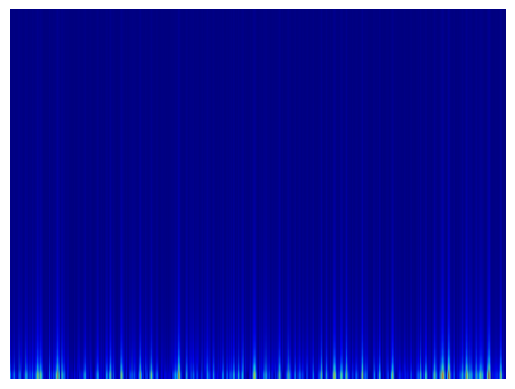

In [50]:
#sad
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("/kaggle/input/yyyyyyyyyyyyyyyyyyyy/trial_4_band_1_ch_55.png")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [51]:
import torch
import torchvision.transforms as transforms
from PIL import Image

def evaluate_single_image(model, image_path, class_labels):
    model.eval()  # Set model to evaluation mode

    # Define transformations (resize, convert to tensor, normalize)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Adjust based on model input size
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.1, 0.1, 0.1], std=[0.1, 0.1, 0.1])  # Adjust based on training settings
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert("L")  # Ensure it's in RGB format
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Perform inference
    with torch.no_grad():
        output = model(image).logits
        predicted_class = torch.argmax(output, dim=1).item()

    # Get class label
    class_label = class_labels[predicted_class] if class_labels else f"Class {predicted_class}"
    print(f"Predicted Class: {class_label}")

# Example usage
image_path = "/kaggle/input/yyyyyyyyyyyyyyyyyyyy/trial_4_band_1_ch_55.png"  # Replace with actual image path
class_labels = ['Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']  # Modify based on your dataset
evaluate_single_image(model, image_path, class_labels)

Predicted Class: Sad
